# Model inversion attack results (iter_*.csv)

This notebook reads the per-iteration CSV logs produced by `recovery.py` → `attack.py` (via `csv_logging.py`).

Requested steps implemented:
1. Read all CSV files starting with `iter_` into a single dataframe called `iter_df`.
2. Filter rows to keep only `iden == "0-59"`.
3. Group by `run_type` and plot: x=`current_iter`, y=`acc`, label=`run_type`.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Folder containing the iter_*.csv logs
DATA_DIR = Path('assg_1_data_log_loss/protection_results_loss_func_log_loss')
assert DATA_DIR.exists(), f'Not found: {DATA_DIR.resolve()}'
DATA_DIR.resolve()

PosixPath('/Users/andriusresetnikovas/University/data_protection_technologies/assg_1/data_protection_tech_assg_1/assg_1_data_log_loss/protection_results_loss_func_log_loss')

In [8]:
# 1) Read all iter_*.csv into a single dataframe called iter_df
iter_csv_paths = sorted(DATA_DIR.glob('iter_*.csv'))
if not iter_csv_paths:
    raise FileNotFoundError(f'No files matching iter_*.csv under {DATA_DIR.resolve()}')

dfs = []
for p in iter_csv_paths:
    df = pd.read_csv(p)
    df['source_file'] = p.name
    dfs.append(df)

iter_df = pd.concat(dfs, ignore_index=True)

print('Loaded files:', len(iter_csv_paths))
print('iter_df shape:', iter_df.shape)
display(iter_df.head())
print('run_type values:', sorted(iter_df['run_type'].dropna().unique().tolist()))
print('iden values (sample):', iter_df['iden'].dropna().unique()[:10])

Loaded files: 6
iter_df shape: (300, 9)


,run_type,iden,current_iter,max_iter,prior_loss,iden_loss,total_loss,acc,source_file
0,base,0-59,300,3000,4.754,1.197,124.444,0.250,iter_base_max3000_20260226-1138.csv
1,base,0-59,600,3000,3.820,0.155,19.286,0.433,iter_base_max3000_20260226-1138.csv
2,base,0-59,900,3000,3.843,0.104,14.208,0.417,iter_base_max3000_20260226-1138.csv
3,base,0-59,1200,3000,3.559,0.070,10.608,0.583,iter_base_max3000_20260226-1138.csv
4,base,0-59,1500,3000,3.267,0.014,4.709,0.450,iter_base_max3000_20260226-1138.csv


run_type values: ['base', 'bb', 'bb_cross_entr', 'bb_double_sigm', 'bb_top1', 'bb_top5']
iden values (sample): ['0-59' '60-119' '120-179' '180-239' '240-299']


In [20]:
# Run-type canonicalization + label mapping

# NOTE: your CSVs historically used 'bb_double_sigm'.
# The notebook uses 'dd_double_sigm' as the canonical name.
RUN_TYPES = ['base', 'bb', 'dd_double_sigm', 'bb_top1', 'bb_top5', 'bb_cross_entr']

CANONICAL_RUN_TYPE = {
    'bb_double_sigm': 'dd_double_sigm',
}

def canonicalize_run_type(run_type: str) -> str:
    s = str(run_type).strip()
    return CANONICAL_RUN_TYPE.get(s, s)

# Edit the VALUES in this dict to rename legend labels.
# Keys are the canonical run_type names.
RUN_TYPE_LABELS = {
    'base': 'white-box, Loss=cross_entropy',
    'bb': 'black-box, Loss=negative_log',
    'bb_cross_entr': 'black-box, Loss=cross_entropy',
    'dd_double_sigm': 'dd_double_sigm',
    'bb_top1': 'bb_top1',
    'bb_top5': 'bb_top5',
}

# Plot selection helpers
EXCLUDE_RUN_TYPES_PLOT_1_2 = {'base', 'bb_cross_entr'}
INCLUDE_RUN_TYPES_PLOT_3 = {'base', 'bb', 'bb_cross_entr'}

# Apply canonicalization to iter_df in-place (keeps later code simple).
iter_df['run_type'] = iter_df['run_type'].map(canonicalize_run_type)

# Optional: sanity-check run_types are as expected
found_run_types = sorted(iter_df['run_type'].dropna().unique().tolist())
print('run_type values (canonicalized):', found_run_types)
unexpected = sorted(set(found_run_types) - set(RUN_TYPES))
if unexpected:
    print('WARNING: unexpected run_type(s) found:', unexpected)

run_type values (canonicalized): ['base', 'bb', 'bb_cross_entr', 'bb_top1', 'bb_top5', 'dd_double_sigm']


In [21]:
# 2) Filter rows, leaving only iden == '0-59'
iter_df_0_59 = iter_df[iter_df['iden'].astype(str).str.strip() == '0-59'].copy()

print('iter_df_0_59 shape:', iter_df_0_59.shape)
display(iter_df_0_59.sort_values(['run_type', 'current_iter']).head(12))

iter_df_0_59 shape: (60, 9)


,run_type,iden,current_iter,max_iter,prior_loss,iden_loss,total_loss,acc,source_file
0,base,0-59,300,3000,4.754,1.197,124.444,0.250,iter_base_max3000_20260226-1138.csv
1,base,0-59,600,3000,3.820,0.155,19.286,0.433,iter_base_max3000_20260226-1138.csv
2,base,0-59,900,3000,3.843,0.104,14.208,0.417,iter_base_max3000_20260226-1138.csv
3,base,0-59,1200,3000,3.559,0.070,10.608,0.583,iter_base_max3000_20260226-1138.csv
4,base,0-59,1500,3000,3.267,0.014,4.709,0.450,iter_base_max3000_20260226-1138.csv
5,base,0-59,1800,3000,2.985,0.021,5.038,0.583,iter_base_max3000_20260226-1138.csv
6,base,0-59,2100,3000,2.849,0.037,6.542,0.567,iter_base_max3000_20260226-1138.csv
7,base,0-59,2400,3000,2.374,0.010,3.418,0.567,iter_base_max3000_20260226-1138.csv
8,base,0-59,2700,3000,1.911,0.006,2.533,0.600,iter_base_max3000_20260226-1138.csv
9,base,0-59,3000,3000,1.462,0.005,1.999,0.633,iter_base_max3000_20260226-1138.csv


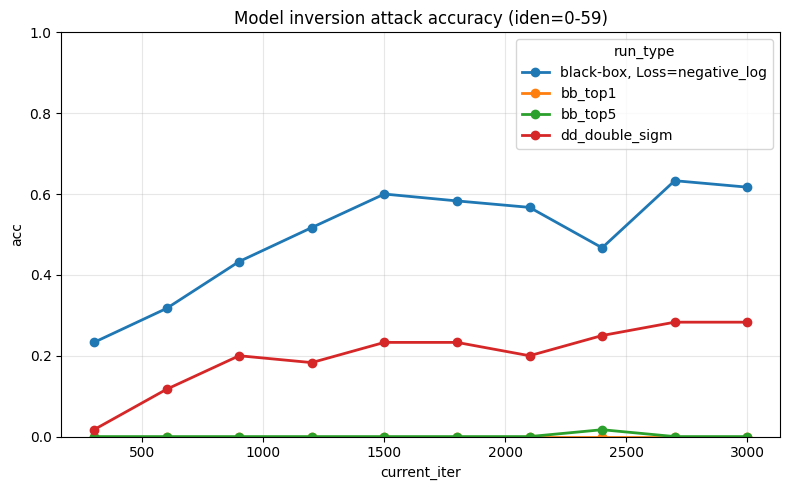

In [22]:
# 3) Plot 1: acc vs current_iter for iden=0-59 (exclude: base, bb_cross_entr)

plot_df = (
    iter_df_0_59
    .groupby(['run_type', 'current_iter'], as_index=False)
    .agg(acc=('acc', 'mean'))
    .sort_values(['run_type', 'current_iter'])
)

plot_df = plot_df[~plot_df['run_type'].isin(EXCLUDE_RUN_TYPES_PLOT_1_2)].copy()

plt.figure(figsize=(8, 5))
for run_type, g in plot_df.groupby('run_type', sort=True):
    label = RUN_TYPE_LABELS.get(str(run_type), str(run_type))
    plt.plot(g['current_iter'], g['acc'], marker='o', linewidth=2, label=label)

plt.xlabel('current_iter')
plt.ylabel('acc')
plt.title('Model inversion attack accuracy (iden=0-59)')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title='run_type')
plt.tight_layout()
plt.show()

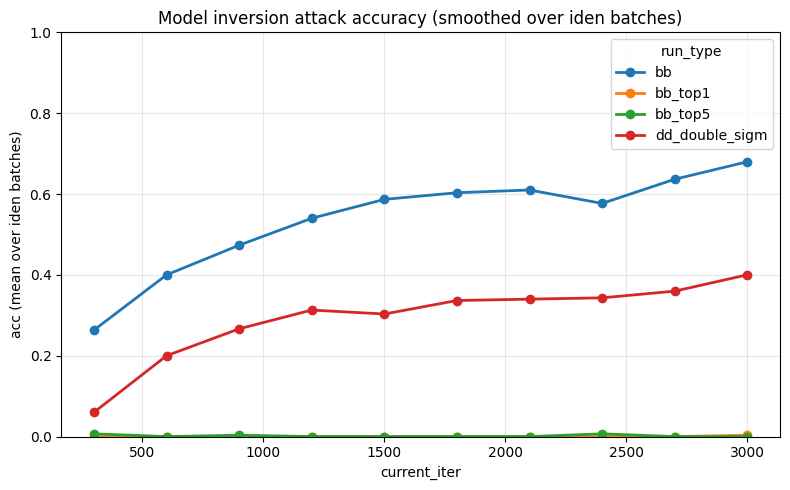

In [ ]:
# Plot 2: smoothed curve by averaging across all identity batches (iden ranges)
# Excludes: base, bb_cross_entr

smooth_df = (
    iter_df
    .assign(iden=lambda d: d['iden'].astype(str).str.strip())
    .groupby(['run_type', 'iden', 'current_iter'], as_index=False)
    .agg(acc=('acc', 'mean'))
    .groupby(['run_type', 'current_iter'], as_index=False)
    .agg(acc=('acc', 'mean'))
    .sort_values(['run_type', 'current_iter'])
)

smooth_df = smooth_df[~smooth_df['run_type'].isin(EXCLUDE_RUN_TYPES_PLOT_1_2)].copy()

plt.figure(figsize=(8, 5))
for run_type, g in smooth_df.groupby('run_type', sort=True):
    label = RUN_TYPE_LABELS.get(str(run_type), str(run_type))
    plt.plot(g['current_iter'], g['acc'], marker='o', linewidth=2, label=label)

plt.xlabel('Iterations')
plt.ylabel('''Attack accuracy (smoothed over iden batches)''')
plt.title('''Attack accuracy based on victim's output modes''')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title='run_type')
plt.tight_layout()
plt.show()

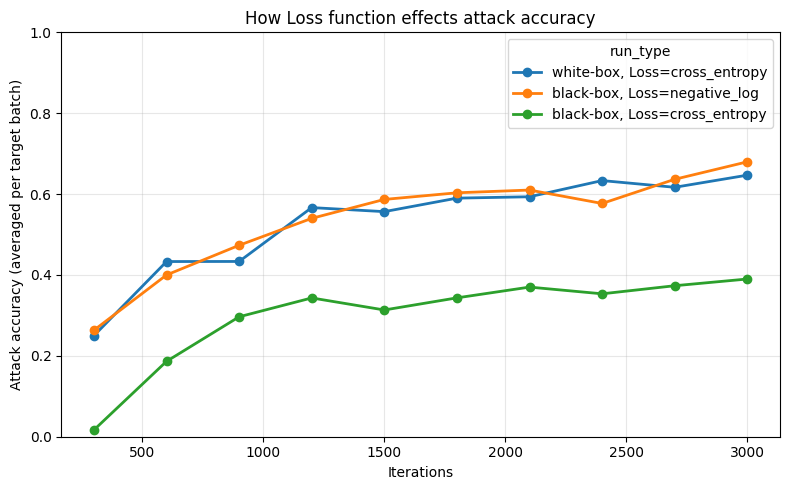

In [24]:
# Plot 3: smoothed curve, but ONLY for runtypes: bb_cross_entr, bb, base

smooth_df_plot3 = (
    iter_df
    .assign(iden=lambda d: d['iden'].astype(str).str.strip())
    .groupby(['run_type', 'iden', 'current_iter'], as_index=False)
    .agg(acc=('acc', 'mean'))
    .groupby(['run_type', 'current_iter'], as_index=False)
    .agg(acc=('acc', 'mean'))
    .sort_values(['run_type', 'current_iter'])
)

smooth_df_plot3 = smooth_df_plot3[smooth_df_plot3['run_type'].isin(INCLUDE_RUN_TYPES_PLOT_3)].copy()

plt.figure(figsize=(8, 5))
for run_type, g in smooth_df_plot3.groupby('run_type', sort=True):
    label = RUN_TYPE_LABELS.get(str(run_type), str(run_type))
    plt.plot(g['current_iter'], g['acc'], marker='o', linewidth=2, label=label)

plt.xlabel('Iterations')
plt.ylabel('Attack accuracy (averaged per target batch)')
plt.title('How Loss function effects attack accuracy')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title='run_type')
plt.tight_layout()
plt.show()

In [19]:
# Join all summary_*.csv files and write a combined CSV

summary_csv_paths = sorted(DATA_DIR.glob('summary_*.csv'))
if not summary_csv_paths:
    raise FileNotFoundError(f'No files matching summary_*.csv under {DATA_DIR.resolve()}')

summary_dfs = []
for p in summary_csv_paths:
    df = pd.read_csv(p)
    df['source_file'] = p.name
    summary_dfs.append(df)

summary_df = pd.concat(summary_dfs, ignore_index=True)
display(summary_df)

out_path = DATA_DIR / 'joined_run_type_log_loss_summary.csv'
summary_df.to_csv(out_path, index=False)
print('Wrote:', out_path.resolve())

,run_type,max_iter,acc,acc_5,acc_var,acc_var5,source_file
0,base,3000,0.719,0.914,0.002,0.001,summary_base_max3000_20260226-1138.csv
1,bb_cross_entr,3000,0.481,0.613,0.002,0.000,summary_bb_cross_entr_max3000_20260226-1204.csv
2,bb_double_sigm,3000,0.451,0.571,0.001,0.001,summary_bb_double_sigm_max3000_20260226-1304.csv
3,bb,3000,0.709,0.910,0.002,0.001,summary_bb_max3000_20260226-1143.csv
4,bb_top1,3000,0.001,0.002,0.000,0.000,summary_bb_top1_max3000_20260226-1148.csv
5,bb_top5,3000,0.004,0.005,0.000,0.000,summary_bb_top5_max3000_20260226-1151.csv


Wrote: /Users/andriusresetnikovas/University/data_protection_technologies/assg_1/data_protection_tech_assg_1/assg_1_data_log_loss/protection_results_loss_func_log_loss/joined_run_type_log_loss_summary.csv
